In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Anomaly

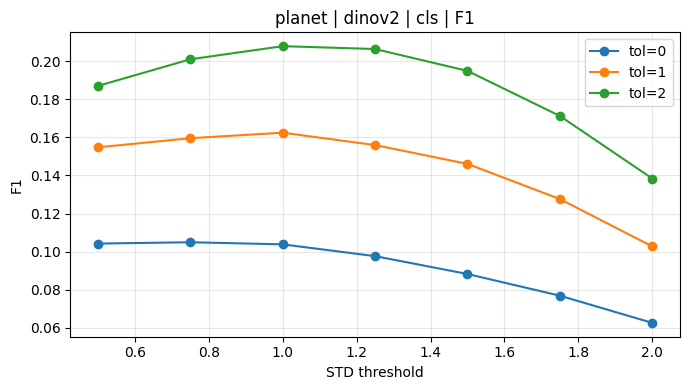

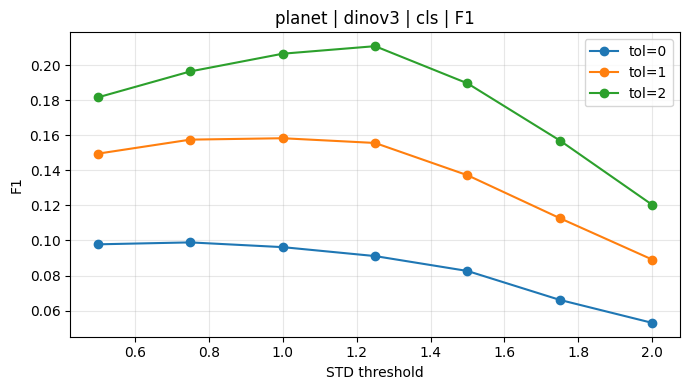

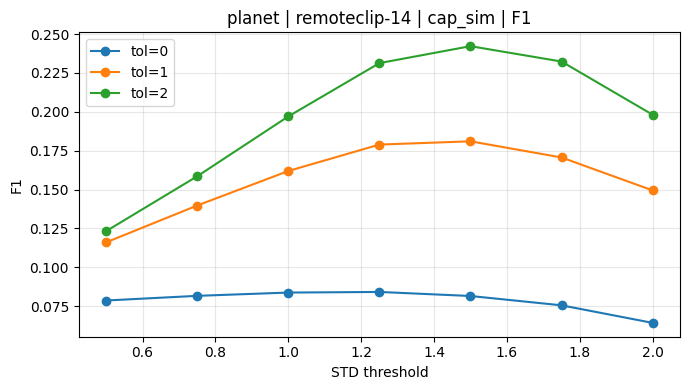

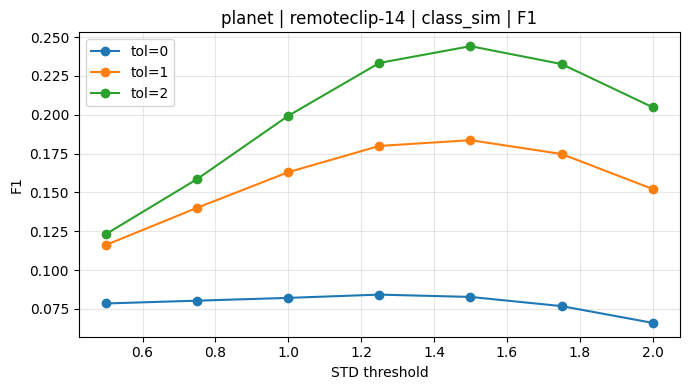

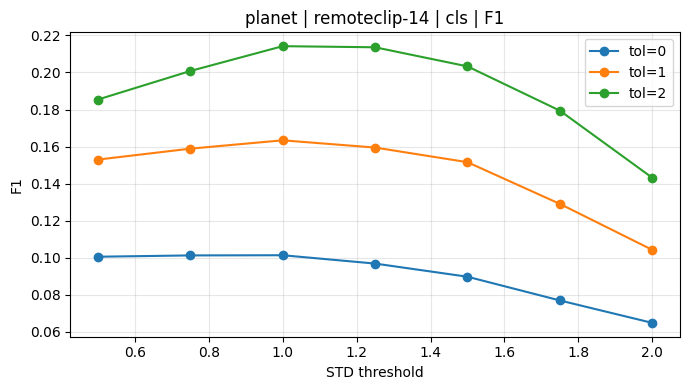

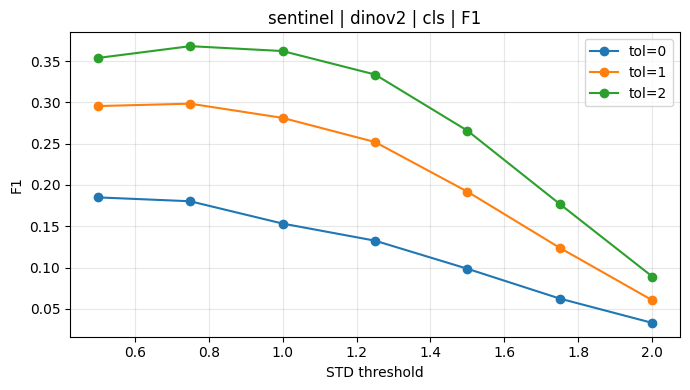

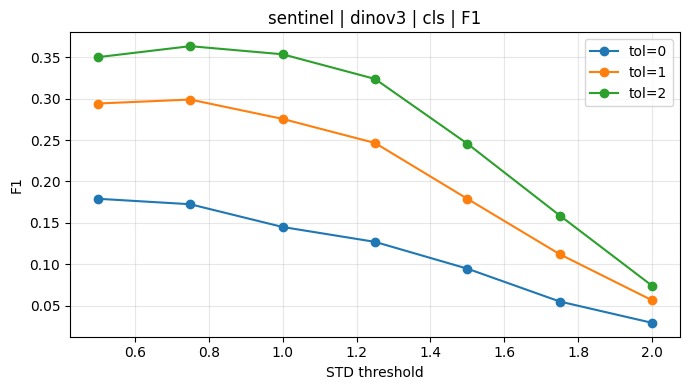

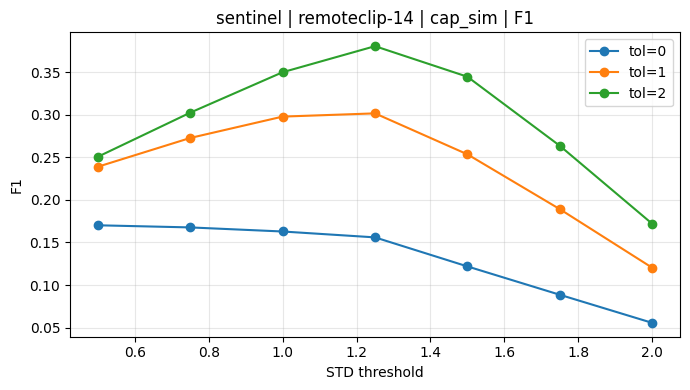

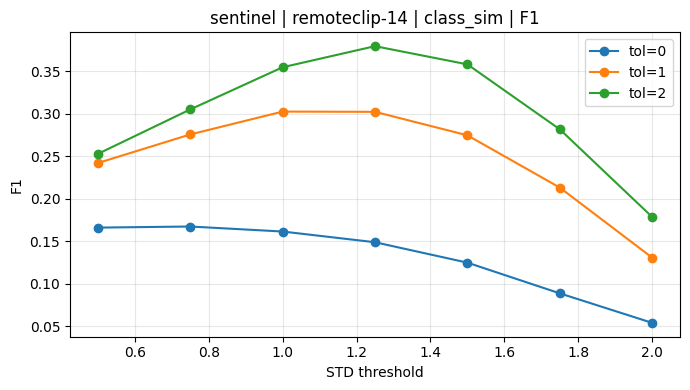

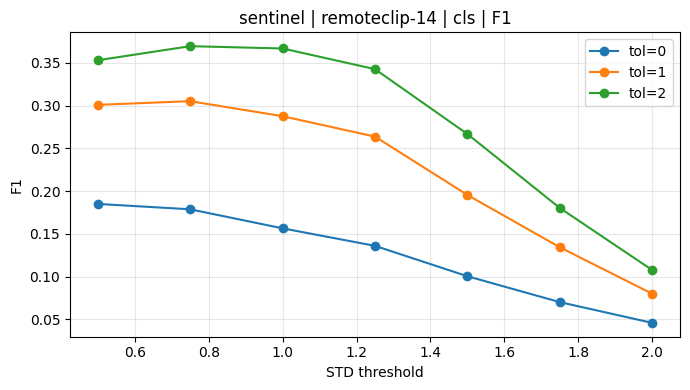

In [10]:
df = pd.read_csv("/home/gridsan/manderson/skyscraper-s2/out/anomaly/anomaly_metrics_summary.csv")

# Keep only STD values from 0.5 to 2.0
df = df[df["std"].between(0.5, 2.0)]

#metrics = ["Accuracy", "Precision", "Recall", "F1"]
metrics = ["F1"]

feat_types = ["cls", "cap_sim", "class_sim"]

for (satellite, backbone, feat_type), group in df.groupby(
    ["satellite", "backbone", "feat_type"]
):
    group = group.sort_values(["std", "tol"])

    for metric in metrics:
        plt.figure(figsize=(7, 4))

        for tol, tol_group in group.groupby("tol"):
            tol_group = tol_group.sort_values("std")
            plt.plot(
                tol_group["std"],
                tol_group[metric],
                marker="o",
                label=f"tol={tol:g}",
            )

        plt.title(f"{satellite} | {backbone} | {feat_type} | {metric}")
        plt.xlabel("STD threshold")
        plt.ylabel(metric)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

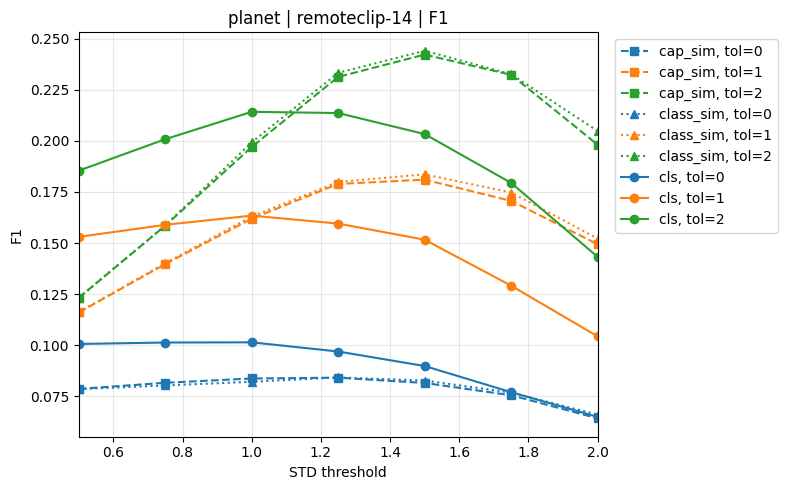

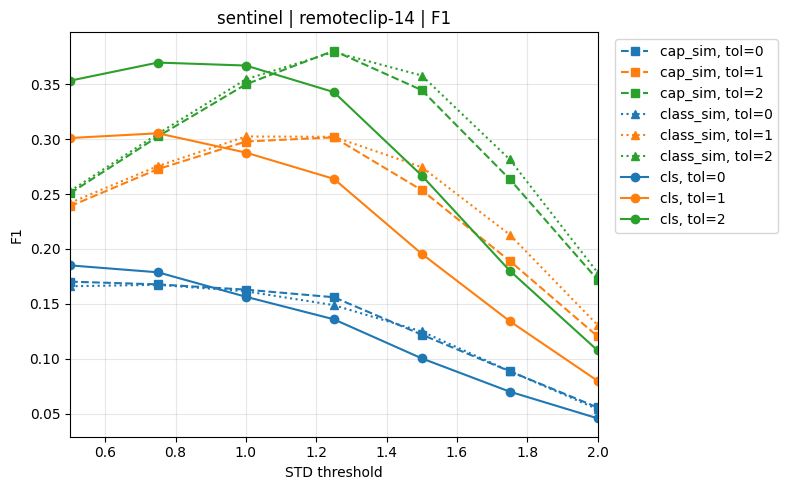

In [9]:
metrics = ["F1"]
feat_types = ["cls", "cap_sim", "class_sim"]

plot_df = df[
    (df["backbone"] == "remoteclip-14")
    & (df["feat_type"].isin(feat_types))
    & (df["std"].between(0.5, 2.0))
].copy()

# Same color for each tolerance
tols = sorted(plot_df["tol"].unique())
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

tol_colors = {
    tol: color_cycle[i % len(color_cycle)]
    for i, tol in enumerate(tols)
}

# Different line and marker styles for each feature type
feat_styles = {
    "cls": {
        "linestyle": "-",
        "marker": "o",
    },
    "cap_sim": {
        "linestyle": "--",
        "marker": "s",
    },
    "class_sim": {
        "linestyle": ":",
        "marker": "^",
    },
}

for satellite, satellite_df in plot_df.groupby("satellite"):
    for metric in metrics:
        plt.figure(figsize=(8, 5))

        for (feat_type, tol), group in satellite_df.groupby(
            ["feat_type", "tol"]
        ):
            group = group.sort_values("std")

            plt.plot(
                group["std"],
                group[metric],
                color=tol_colors[tol],
                linestyle=feat_styles[feat_type]["linestyle"],
                marker=feat_styles[feat_type]["marker"],
                label=f"{feat_type}, tol={tol:g}",
            )

        plt.xlim(0.5, 2.0)
        plt.xlabel("STD threshold")
        plt.ylabel(metric)
        plt.title(f"{satellite} | remoteclip-14 | {metric}")
        plt.grid(alpha=0.3)
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

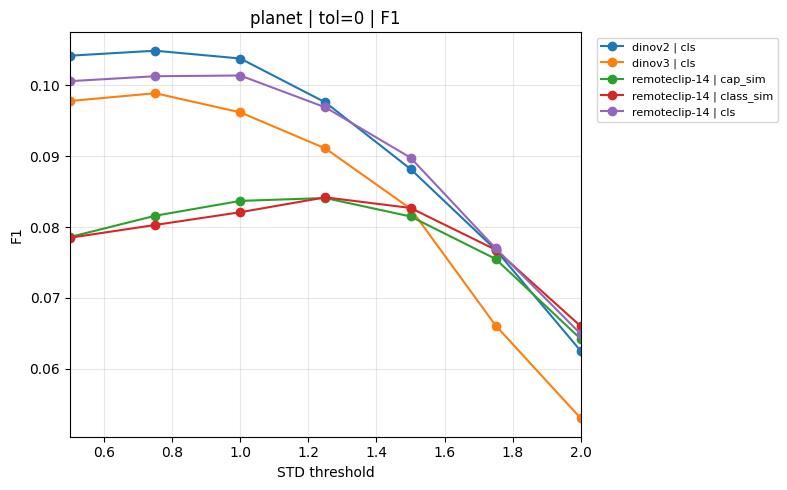

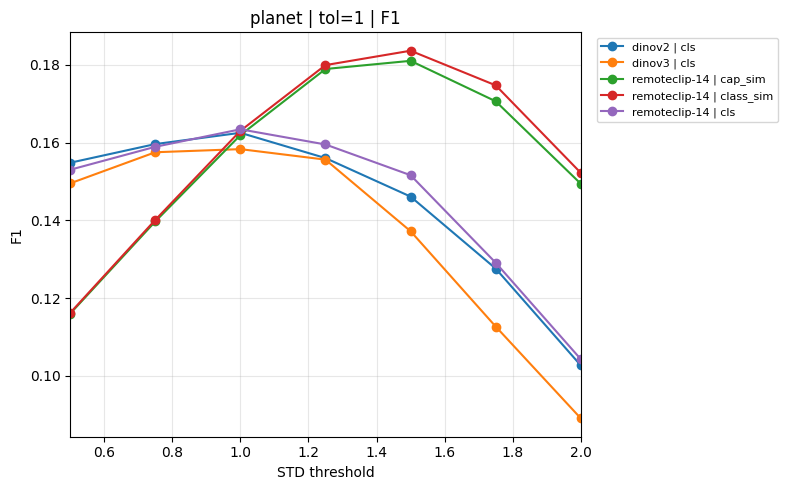

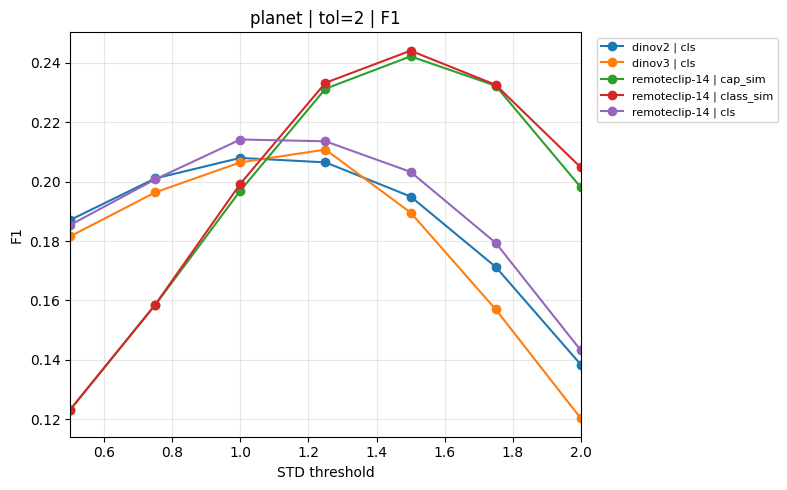

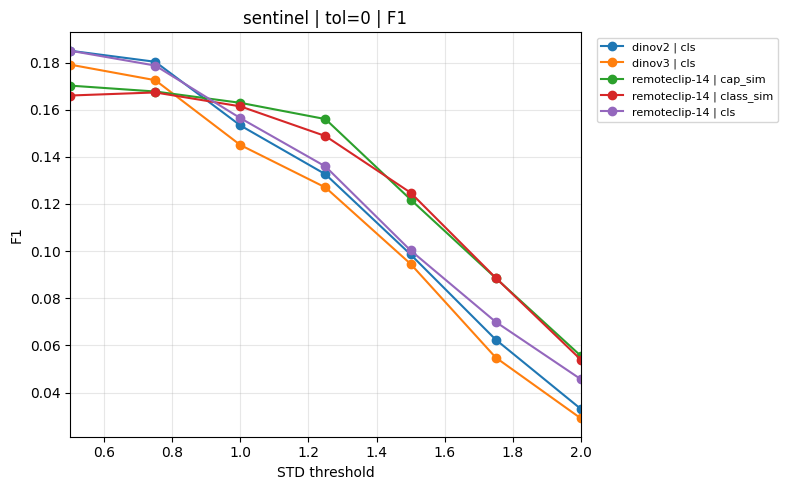

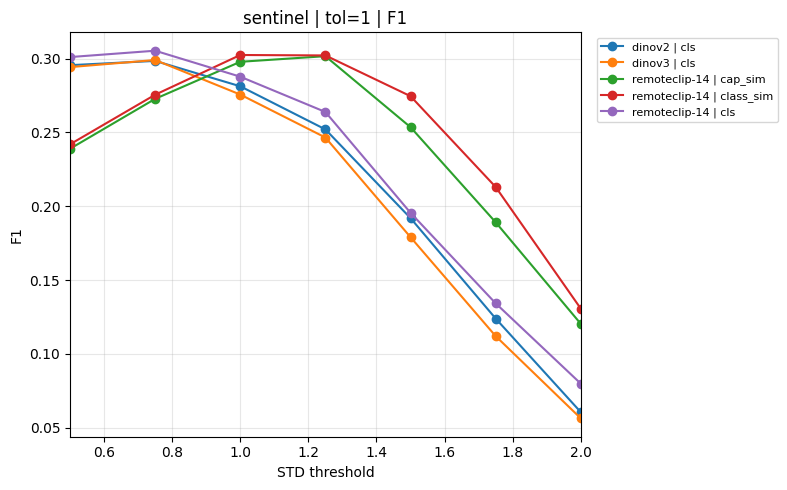

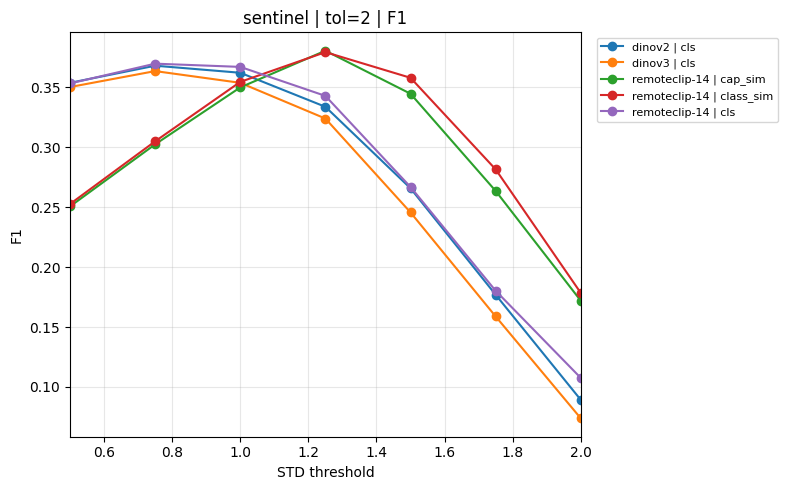

In [12]:
metrics = ["F1"]
satellites = ["planet", "sentinel"]

for satellite in satellites:
    satellite_df = df[df["satellite"] == satellite]

    for tol, tol_df in satellite_df.groupby("tol"):
        for metric in metrics:
            plt.figure(figsize=(8, 5))

            for (backbone, feat_type), group in tol_df.groupby(
                ["backbone", "feat_type"]
            ):
                group = group.sort_values("std")

                plt.plot(
                    group["std"],
                    group[metric],
                    marker="o",
                    label=f"{backbone} | {feat_type}",
                )

            plt.xlim(0.5, 2.0)
            plt.title(f"{satellite} | tol={tol:g} | {metric}")
            plt.xlabel("STD threshold")
            plt.ylabel(metric)
            plt.grid(alpha=0.3)
            plt.legend(
                bbox_to_anchor=(1.02, 1),
                loc="upper left",
                fontsize=8,
            )
            plt.tight_layout()
            plt.show()

## CPD

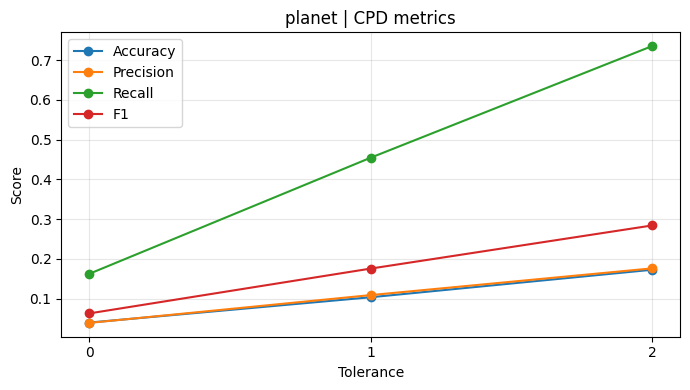

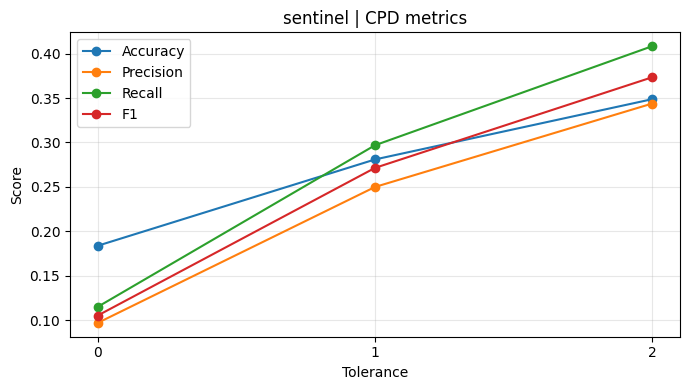

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "/home/gridsan/manderson/skyscraper-s2/out/cpd/cpd_metrics_summary.csv"
)

metrics = ["Accuracy", "Precision", "Recall", "F1"]

# One plot per satellite
for satellite, group in df.groupby("satellite"):
    group = group.sort_values("tol")

    plt.figure(figsize=(7, 4))

    for metric in metrics:
        plt.plot(
            group["tol"],
            group[metric],
            marker="o",
            label=metric,
        )

    plt.title(f"{satellite} | CPD metrics")
    plt.xlabel("Tolerance")
    plt.ylabel("Score")
    plt.xticks(sorted(group["tol"].unique()))
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()